# Load and Plot SWOT EXPERT Data over PACE Data

Authors: Lexi Jones-Kellett, Sarah Lang, Tasha Snow

Please check that SWOT data looks good in SWOT_velocities_maps

- Overlaid streamlines on PACE derived variables (chl-a, pico, syn, pro)

In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import netCDF4 as nc
import re
from datetime import datetime

#%matplotlib widget # magic matplotlib (if you want that)

In [2]:
%pip install jaxparrow
from jaxparrow import cyclogeostrophy
from jaxparrow import geostrophy
import jax.numpy as jnp
import jaxparrow as jxr

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [4]:
earthaccess.login(persist=True)

In [5]:
smoothing_factor=15

### To do: Below, add date requested in following formats. Input correct AVISO data for eddy of interest. Input correct MOANA file

In [6]:
date_requested = '20240508'
pacedate="2024-05-08"

In [7]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

In [8]:
moana_ds = xr.open_dataset('data/moana_Edward_05082024.nc') # should rename this with file extention .nc
mlon = moana_ds.variables['longitude'] 
mlat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana'] 

In [9]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77411
-67.887146


Log into earthaccess

In [10]:
auth = earthaccess.login(persist=True)

Check the names of the SWOT datasets available on earthaccess

In [11]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [12]:
#Following function written with assistance of AI
def remove_swath_edges(data_array, edge_pixels):
    """
    Simple approach: remove edge pixels from all continuous non-NaN segments
    """
    result = jnp.array(data_array)
    n_rows, n_cols = data_array.shape
    
    for i in range(n_rows):
        # Convert to numpy for gap detection
        row_data = np.array(data_array[i, :])
        valid_mask = ~np.isnan(row_data)
        
        # Find where valid data starts and ends
        if np.any(valid_mask):
            # Find all valid segments
            diff = np.diff(valid_mask.astype(int))
            segment_starts = np.where(diff == 1)[0] + 1
            segment_ends = np.where(diff == -1)[0] + 1
            
            # Handle edge cases
            if valid_mask[0]:
                segment_starts = np.insert(segment_starts, 0, 0)
            if valid_mask[-1]:
                segment_ends = np.append(segment_ends, n_cols)
            
            # Remove edges from each segment
            for start, end in zip(segment_starts, segment_ends):
                if (end - start) > 2 * edge_pixels:
                    # Remove left edge
                    result = result.at[i, start:start + edge_pixels].set(jnp.nan)
                    # Remove right edge
                    result = result.at[i, end - edge_pixels:end].set(jnp.nan)
    
    return result

In [13]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

Get all dates with SWOT swaths through the bounding box

Get data from a specific date

NOTE: 2024/05/23 isn't cropping

In [14]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


There are 2 swaths on the date of interest

Open a single dataset.

NOTE: Will need to point to different indices if you change the bounding box

In [15]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [16]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [17]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

In [18]:
ds=ds1_masked
ssh=ds.ssha_karin_2+ds.height_cor_xover
lats=ds.latitude
lons=ds.longitude
ds=ds.assign(ssha=ssh)
ds2=ds2_masked
ssh2=ds2.ssha_karin_2+ds2.height_cor_xover
lats2=ds2.latitude
lons2=ds2.longitude
ds2=ds2.assign(ssha=ssh2)

In [19]:
ug, vg, j, j1, j12, j3 = geostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
ug2, vg2, j, j1, j12, j3 = geostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2)) #they inversed this!

In [20]:
pixel_num=2 #This number will change per 
ug = remove_swath_edges(ug, edge_pixels=pixel_num)
ug2 = remove_swath_edges(ug2,edge_pixels=pixel_num)
vg = remove_swath_edges(vg,edge_pixels=pixel_num)
vg2 = remove_swath_edges(vg2,edge_pixels=pixel_num)

In [21]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain(data_array,u,v,wfl):

    lats = jnp.array(data_array.latitude.values)
    lons = jnp.array(data_array.longitude.values)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=jnp.array(strain)/f_coriolis 
    OkuboWeiss=(du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2 - (dv_dx - du_dy) ** 2 #double check and propagate to other scripts
    OkuboWeiss=OkuboWeiss/4

    return vorticity,strain,OkuboWeiss

In [22]:
vort,strain,OkuboWeiss=compute_normalized_vorticity_strain(ds,ug,vg,smoothing_factor)
vort2,strain2,OkuboWeiss2=compute_normalized_vorticity_strain(ds2,ug2,vg2,smoothing_factor) 

In [23]:
pixel_num=2 #This number will change per 
vort = remove_swath_edges(vort, edge_pixels=pixel_num)
vort2 = remove_swath_edges(vort2,edge_pixels=pixel_num)
strain = remove_swath_edges(strain,edge_pixels=pixel_num)
strain2 = remove_swath_edges(strain2,edge_pixels=pixel_num)

### get aviso contour

In [24]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [25]:
contour_lons,contour_lats,center_lon,center_lat = get_eddy_by_ID_date(aviso_ds,pacedate)

(33.7, 37.5)

<Figure size 640x480 with 0 Axes>

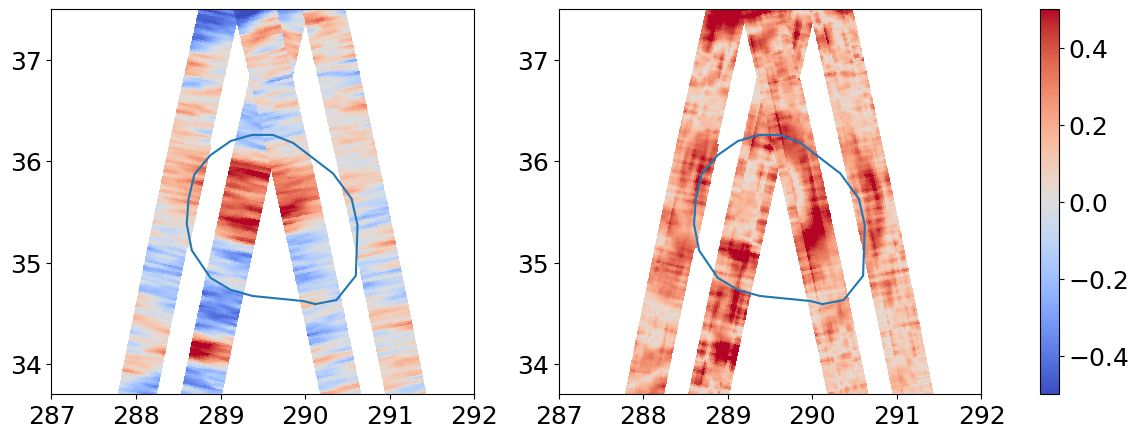

In [26]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)
ax[0].plot(contour_lons,contour_lats)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].plot(contour_lons,contour_lats)

cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

ax[0].set_xlim([287,292])
ax[0].set_ylim([33.7,37.5])
ax[1].set_xlim([287,292])
ax[1].set_ylim([33.7,37.5])

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

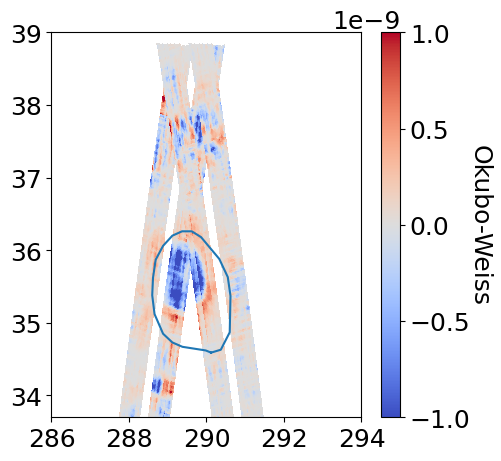

In [27]:
vel=10e-10
plt.clf()

fig,ax=plt.subplots(figsize=(5,5))


plot = plt.pcolormesh(lons,lats,OkuboWeiss,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = plt.pcolormesh(lons2,lats2,OkuboWeiss2,cmap='coolwarm',vmin=-vel,vmax=vel)
plt.plot(contour_lons,contour_lats)

cbar = plt.colorbar(plot)
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=15)
ax.set_xlim([286,294])
ax.set_ylim([33.7,39 ])

Need to add 'height_cor_xover' values to ssh & sla variabiles

### Load in PACE Data, will change for new workflow where netcdfs have chl and poc too

TO DO: There may be two images... the second may be the clear one... may need to change paths[0] to paths[1]

In [28]:
clouds = (0, 100)
tspan=(pacedate,pacedate)
bbox = (lonmin+2, latmin+2, lonmax-2, latmax-2)

#earthaccess is not working for data post 2025
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    #temporal=("2024-12-01", "2024-12-10"),
    bounding_box=bbox,
    cloud_cover=clouds,
)

In [29]:
paths = earthaccess.open(results) #'streaming' data

datatree = open_datatree(paths[0])
datatree
dataset = xr.merge(datatree.to_dict().values())
dataset
dataset = dataset.set_coords(("longitude", "latitude"))

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_175/439396501.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  datatree = open_datatree(paths[0])


In [30]:
# h=str(paths[0])
# datey=h[64:72]

## Load NEUROST data from PO.DAAC

In [31]:
t1=datetime(int(date_requested[0:4]),int(date_requested[5]),int(date_requested[7]))
t2=t1    
tspan_neurost = ("2023-01-01", "2023-01-30") #ignore, due to incorrect date indexing on podaac

bbox=(lonmin,latmin,lonmax,latmax)
results_NEUROST = earthaccess.search_data(
    short_name="NEUROST_SSH-SST_L4_V2024.0",
    temporal=tspan_neurost)

paths = earthaccess.open(results_NEUROST) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/532 [00:00<?, ?it/s]

In [32]:
#account for issues in NEUROST indexing
fname_pattern = re.compile(r"NeurOST_SSH-SST_(\d{8})_\d{8}\.nc", re.IGNORECASE)

def extract_analysis_date(fname):
    m = fname_pattern.search(fname)
    if not m:
        return None
    return datetime.strptime(m.group(1), "%Y%m%d")

filtered = []
for obj in paths:
    s = str(obj)

    # extract filename from repr
    m = fname_pattern.search(s)
    if not m:
        continue

    date = datetime.strptime(m.group(1), "%Y%m%d")

    if t1 <= date <= t2:
        filtered.append(obj)

print("Matched:", len(filtered), "files")

Matched: 1 files


In [33]:
neurostdat=xr.open_dataset(filtered[0]);
neurostdat = crop_dataset_by_lat_lon(neurostdat,latmin,latmax,lonmin,lonmax)
lon_n=neurostdat["longitude"].values
lat_n=neurostdat["latitude"].values
ug_n=neurostdat["ugos"].values
vg_n=neurostdat["vgos"].values

In [34]:
neurostdat

<xarray.Dataset> Size: 152kB
Dimensions:                 (latitude: 53, longitude: 79, time: 1)
Coordinates:
  * longitude               (longitude) float64 632B 286.3 286.4 ... 294.0 294.1
  * latitude                (latitude) float64 424B 33.6 33.7 33.8 ... 38.7 38.8
  * time                    (time) datetime64[ns] 8B 2024-05-08
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Data variables:
    sla                     (latitude, longitude, time) float32 17kB 0.31 ......
    adt                     (latitude, longitude, time) float32 17kB 1.032 .....
    ugosa                   (latitude, longitude, time) float32 17kB 0.2365 ....
    vgosa                   (latitude, longitude, time) float32 17kB -0.3092 ...
    sn                      (latitude, longitude, time) float32 17kB 1.296e-0...
    ss                      (latitude, longitude, time) float32 17kB -8.473e-...
    zeta                    (latitude, longitude, time) float32 17kB 1.598e-0...
    ugos                    (latitude, longitude, time) float32 17kB 0.185 .....
    vgos                    (latitude, longitude, time) float32 17kB -0.4262 ...
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-11-26T14:33:55.633872
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

### OSCAR altimetry

In [35]:
results = earthaccess.search_data(
        short_name="OSCAR_L4_OC_INTERIM_V2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
oscar_paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

Number of swaths: 223


QUEUEING TASKS | :   0%|          | 0/223 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/223 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/223 [00:00<?, ?it/s]

In [36]:
ind = 0 
for i in oscar_paths:
    today = str(i).split('.')[-2].split('_')[-1]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

146


In [37]:
oscar_ds = xr.open_dataset(oscar_paths[sel])
oscar_ds = oscar_ds.transpose("time", "latitude", "longitude") # oscar reads in stupid, so just do this line.. trust me ;)
oscar_ds

<xarray.Dataset> Size: 33MB
Dimensions:  (latitude: 719, longitude: 1440, time: 1)
Coordinates:
    lat      (latitude) float64 6kB ...
    lon      (longitude) float64 12kB ...
  * time     (time) object 8B 2024-05-08 00:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    u        (time, latitude, longitude) float64 8MB ...
    v        (time, latitude, longitude) float64 8MB ...
    ug       (time, latitude, longitude) float64 8MB ...
    vg       (time, latitude, longitude) float64 8MB ...
Attributes: (12/36)
    title:                      Ocean Surface Current Analyses Real-time (OSC...
    summary:                    Global, daily, 0.25 degree geostrophic and to...
    keywords:                   ocean currents,ocean circulation,surface curr...
    Conventions:                CF-1.8 Standard Names v77, ACDD-1.3, netcdf 4...
    id:                         OSCAR_L4_OC_INTERIM_V2.0
    history:                    OSCAR 0.25 degree daily version 2.0 replaces ...
    ...                         ...
    geospatial_lon_max:         359.75
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.25 degree
    time_coverage_start:        2024-05-08T00:00:00
    time_coverage_end:          2024-05-08T23:59:59
    date_created:               2024-07-08

In [38]:
def crop_oscar_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.lat >= latmin) & (ds.lat <= latmax) & (ds.lon >= lonmin+360) & (ds.lon <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [39]:
oscar_ds_masked = crop_oscar_by_lat_lon(oscar_ds,latmin,latmax,lonmin,lonmax)
# oscar_ds_masked

In [40]:
#for streamplot
Xlon, Ylat = np.meshgrid(oscar_ds_masked.lon-360, oscar_ds_masked.lat)

In [41]:
#First plot 

In [42]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain_neurost(data_array,u,v,wfl):

    lat1d=data_array.latitude.values
    lon1d=data_array.longitude.values
    Lon2D, Lat2D = np.meshgrid(lon1d, lat1d)
    lats = jnp.array(Lat2D)
    lons = jnp.array(Lon2D)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=jnp.array(strain)/f_coriolis 
    OkuboWeiss=(du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2 - (dv_dx - du_dy) ** 2 #double check and propagate to other scripts
    OkuboWeiss=OkuboWeiss/4

    return vorticity,strain,OkuboWeiss

In [43]:
vort_neurost,strain_neurost,OkuboWeiss_neurost=compute_normalized_vorticity_strain_neurost(neurostdat,np.squeeze(ug_n),np.squeeze(vg_n),8)

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

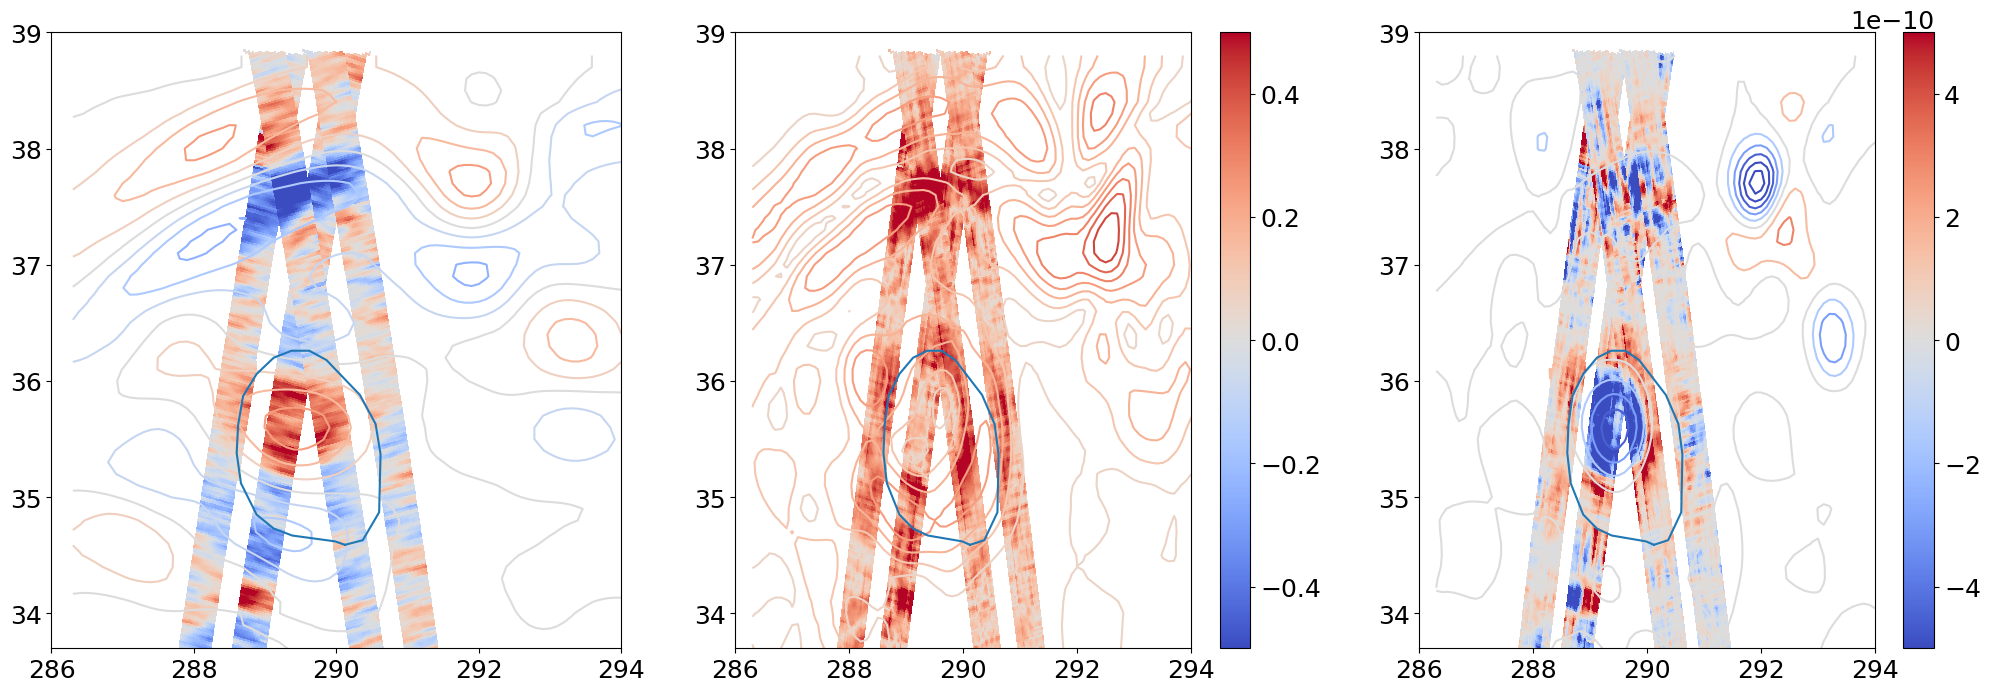

In [44]:
vel=0.5
vel2=5e-10
plt.clf()
dataset=neurostdat
fig,ax=plt.subplots(1,3,figsize=(25,8))

plot = ax[0].contour(dataset.longitude,dataset.latitude,vort_neurost,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)
ax[0].plot(contour_lons,contour_lats)

plot = ax[1].contour(dataset.longitude,dataset.latitude,strain_neurost,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[1])
ax[1].plot(contour_lons,contour_lats)

plot = ax[2].contour(dataset.longitude,dataset.latitude,OkuboWeiss_neurost,cmap='coolwarm',vmin=-vel2,vmax=vel2)
plot = ax[2].pcolormesh(lons,lats,OkuboWeiss,cmap='coolwarm',vmin=-vel2,vmax=vel2)
plot = ax[2].pcolormesh(lons2,lats2,OkuboWeiss2,cmap='coolwarm',vmin=-vel2,vmax=vel2)
plt.plot(contour_lons,contour_lats)
cbar = plt.colorbar(plot,ax=ax[2])

# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])
ax[2].set_xlim([286,294])
ax[2].set_ylim([33.7,39 ])


/tmp/ipykernel_175/2225892072.py:23: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for level, collection in zip(vort_contour.levels, vort_contour.collections):
/tmp/ipykernel_175/2225892072.py:50: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for level, collection in zip(strain_contour.levels, strain_contour.collections):
/tmp/ipykernel_175/2225892072.py:77: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for level, collection in zip(ow_contour.levels, ow_contour.collections):


<Figure size 640x480 with 0 Axes>

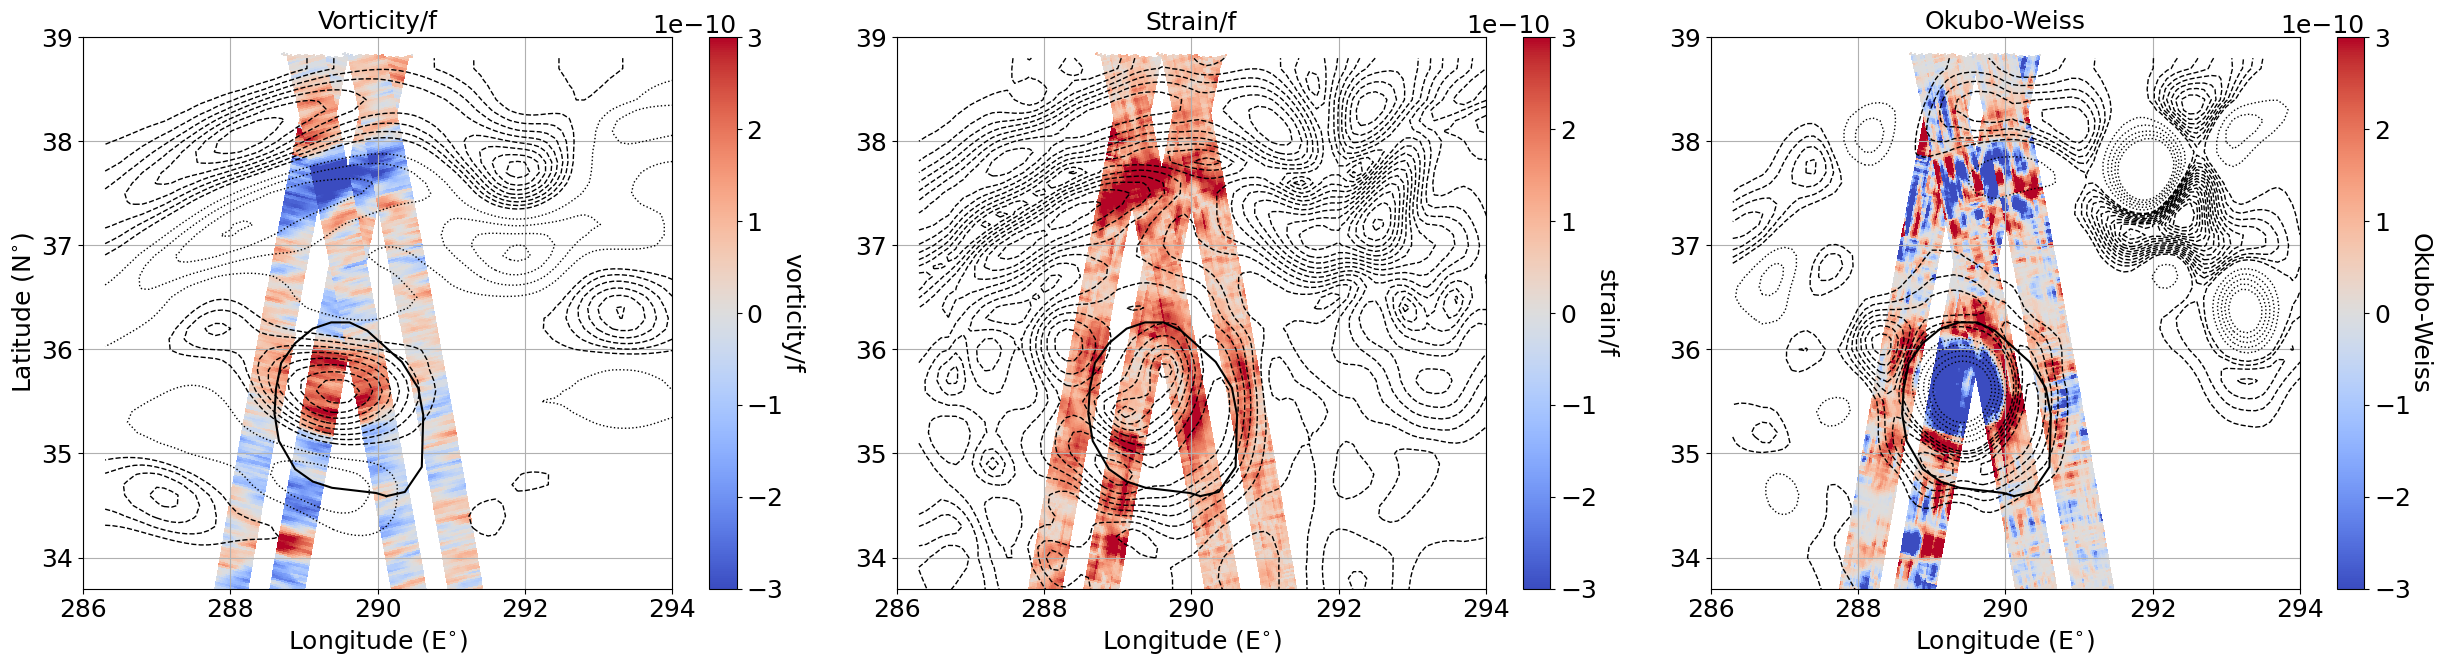

In [49]:
vel=0.5
vel2=3e-10
plt.clf()
dataset=neurostdat
fig,ax=plt.subplots(1,3,figsize=(25,7))

# VORTICITY PLOT - MORE LEVELS
plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)

# Add vorticity contours with MORE levels
n_pos_levels_vort = 15  # More levels for vorticity
n_neg_levels_vort = 8   # More negative levels too
positive_levels_vort = np.linspace(0, vel, n_pos_levels_vort + 1)[1:]
negative_levels_vort = np.linspace(-vel, 0, n_neg_levels_vort + 1)[:-1]
all_levels_vort = np.sort(np.concatenate([negative_levels_vort, positive_levels_vort]))

vort_contour = ax[0].contour(dataset.longitude, dataset.latitude, vort_neurost, 
                            levels=all_levels_vort,
                            vmin=-vel, vmax=vel)

# Style vorticity contours - EXACT SAME AS YOUR SCRIPT
for level, collection in zip(vort_contour.levels, vort_contour.collections):
    collection.set_edgecolor('black')
    if level >= 0:
        collection.set_linestyle('dashed')  # Positive = dashed
        collection.set_linewidth(1.0)
    else:
        collection.set_linestyle('dotted')  # Negative = dotted
        collection.set_linewidth(1.0)

ax[0].plot(contour_lons, contour_lats, color='black', linestyle='solid')  # Black solid line

# STRAIN PLOT - MORE LEVELS
plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)

# Add strain contours with MORE levels
n_pos_levels_strain = 15  # More levels for strain
n_neg_levels_strain = 8   # More negative levels too
positive_levels_strain = np.linspace(0, vel, n_pos_levels_strain + 1)[1:]
negative_levels_strain = np.linspace(-vel, 0, n_neg_levels_strain + 1)[:-1]
all_levels_strain = np.sort(np.concatenate([negative_levels_strain, positive_levels_strain]))

strain_contour = ax[1].contour(dataset.longitude, dataset.latitude, strain_neurost, 
                              levels=all_levels_strain,
                              vmin=-vel, vmax=vel)

# Style strain contours - EXACT SAME AS YOUR SCRIPT
for level, collection in zip(strain_contour.levels, strain_contour.collections):
    collection.set_edgecolor('black')
    if level >= 0:
        collection.set_linestyle('dashed')  # Positive = dashed
        collection.set_linewidth(1.0)
    else:
        collection.set_linestyle('dotted')  # Negative = dotted
        collection.set_linewidth(1.0)

ax[1].plot(contour_lons, contour_lats, color='black', linestyle='solid')  # Black solid line

# OKUBO-WEISS PLOT - FEWER LEVELS (same as your script)
plot = ax[2].pcolormesh(lons,lats,OkuboWeiss,cmap='coolwarm',vmin=-vel2,vmax=vel2)
plot = ax[2].pcolormesh(lons2,lats2,OkuboWeiss2,cmap='coolwarm',vmin=-vel2,vmax=vel2)

# Add Okubo-Weiss contours with FEWER levels (same as your script)
n_pos_levels_ow = 15  # Fewer positive levels for Okubo-Weiss
n_neg_levels_ow = 5   # Fewer negative levels for Okubo-Weiss
positive_levels_ow = np.linspace(0, vel2, n_pos_levels_ow + 1)[1:]
negative_levels_ow = np.linspace(-vel2, 0, n_neg_levels_ow + 1)[:-1]
all_levels_ow = np.sort(np.concatenate([negative_levels_ow, positive_levels_ow]))

ow_contour = ax[2].contour(dataset.longitude, dataset.latitude, OkuboWeiss_neurost, 
                          levels=all_levels_ow,
                          vmin=-vel2, vmax=vel2)

# Style Okubo-Weiss contours - EXACT SAME AS YOUR SCRIPT
for level, collection in zip(ow_contour.levels, ow_contour.collections):
    collection.set_edgecolor('black')
    if level >= 0:
        collection.set_linestyle('dashed')  # Positive = dashed
        collection.set_linewidth(1.0)
    else:
        collection.set_linestyle('dotted')  # Negative = dotted
        collection.set_linewidth(1.0)

ax[2].plot(contour_lons, contour_lats, color='black', linestyle='solid')  # Black solid line

# COMMON SETTINGS FOR ALL SUBPLOTS - SAME AS YOUR SCRIPT
for i in range(3):
    # Set limits
    ax[i].set_xlim([286,294])
    ax[i].set_ylim([33.7,39])
    
    # Add grid and background
    ax[i].grid(True)
    ax[i].set_facecolor('w')
    
    # Labels
    if i == 0:
        ax[i].set_ylabel('Latitude (N$^{\circ}$)')
    ax[i].set_xlabel('Longitude (E$^{\circ}$)')

# Add titles
ax[0].set_title('Vorticity/f')
ax[1].set_title('Strain/f')
ax[2].set_title('Okubo-Weiss')

# Add colorbars
cbar0 = plt.colorbar(plot, ax=ax[0])
cbar0.set_label('vorticity/f', rotation=270, labelpad=15)

cbar1 = plt.colorbar(plot, ax=ax[1])
cbar1.set_label('strain/f', rotation=270, labelpad=15)

cbar2 = plt.colorbar(plot, ax=ax[2])
cbar2.set_label('Okubo-Weiss', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()